In [18]:
import math
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

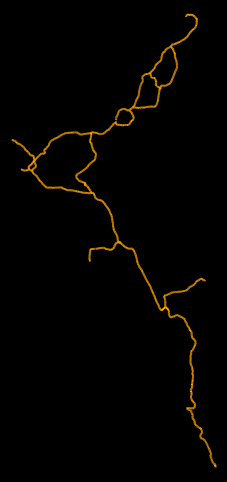

In [21]:
# Load CSV
df = pd.read_csv('../data/network_data.csv')


G = nx.Graph()

# 1. Add nodes (deduplicate by id!)
nodes = df.drop_duplicates(subset="id")

for _, row in nodes.iterrows():
    G.add_node(
        int(row["id"]),
        road=row["road"],  # first occurrence kept (fine for intersections)
        pos=(row["lon"], row["lat"]),
    )

# 2. Create edges using shift
df["from_id"] = df.groupby("road")["id"].shift(1)
df["to_id"] = df["id"]

edges = df.dropna(subset=["from_id"]).copy()

# optional: rename for clarity
edges = edges.rename(columns={"model_type": "type"})

# 3. Add edges
for _, row in edges.iterrows():
    G.add_edge(
        int(row["from_id"]),
        int(row["to_id"]),
        road=row["road"],
        type=row["type"],
        length=row["length"]
    )

# 4. Draw only edges (zoomed to graph bounds)
pos = nx.get_node_attributes(G, "pos")
xs = [xy[0] for xy in pos.values()]
ys = [xy[1] for xy in pos.values()]

min_x, max_x = min(xs), max(xs)
min_y, max_y = min(ys), max(ys)
pad_x = (max_x - min_x) * 0.01
pad_y = (max_y - min_y) * 0.01

fig, ax = plt.subplots(figsize=(6, 6))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="orange", width=1.4)
ax.set_xlim(min_x - pad_x, max_x + pad_x)
ax.set_ylim(min_y - pad_y, max_y + pad_y)
ax.set_aspect("equal", adjustable="box")
ax.set_axis_off()
plt.show()